<a href="https://colab.research.google.com/github/Faitz761/Tugas-Pengolahan-Citra-Digital/blob/main/UTS_PCD_JAWABAN1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

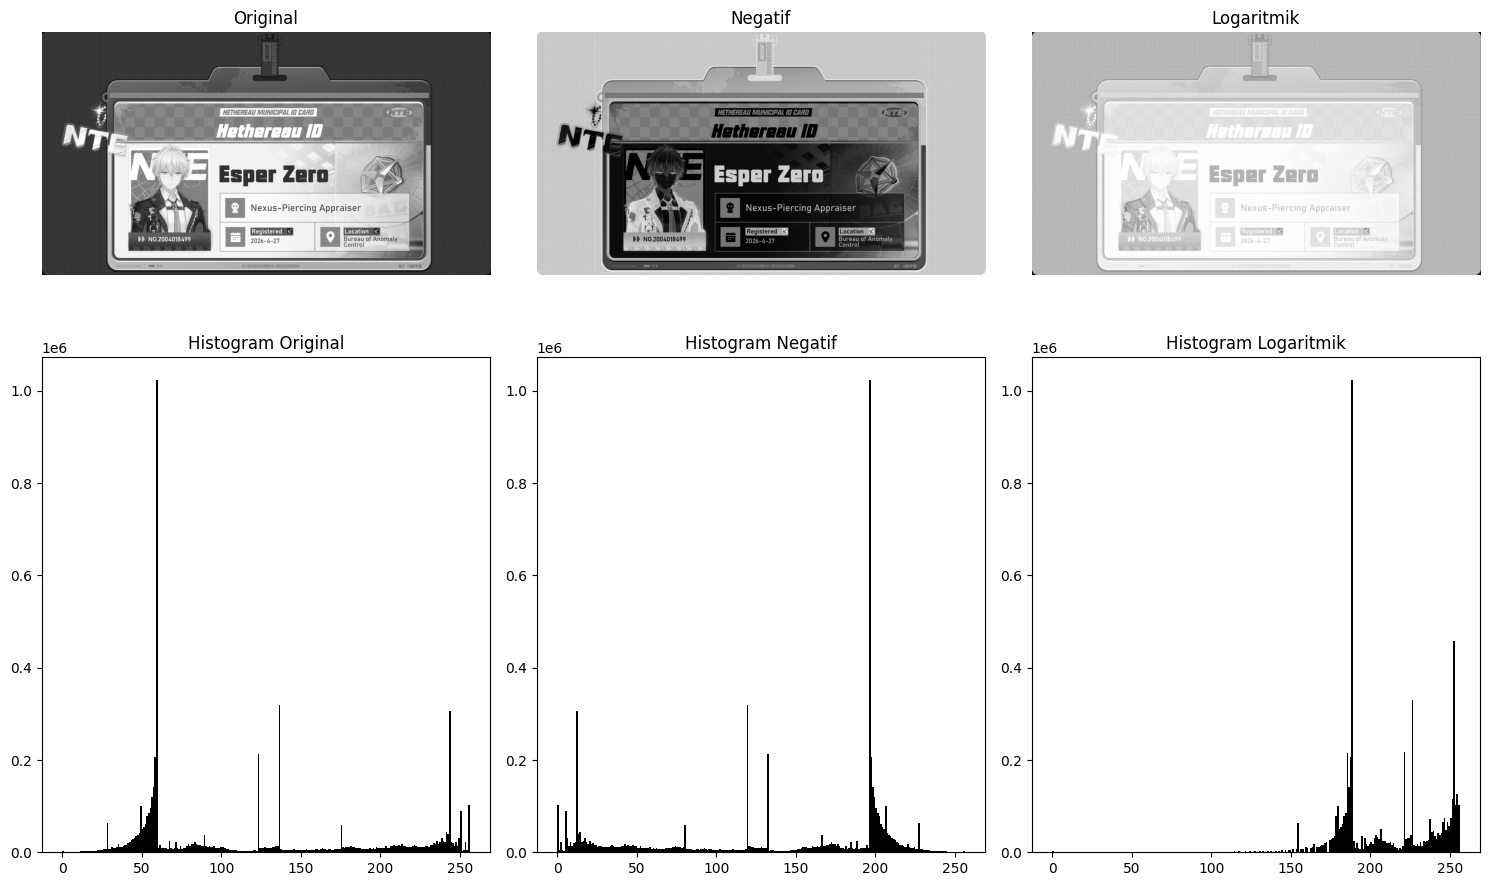

In [5]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 1. Baca citra grayscale
img_path = 'NTE_My_Hethereau_ID_Card.png'
img_original = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

if img_original is None:
    print("Gambar tidak ditemukan! Cek nama file dan lokasinya.")
else:
    # --- Negatif ---
    img_negative = 255 - img_original

    # --- Logaritmik ---
    max_f = float(np.max(img_original))

    # Hitung nilai c
    if max_f > 0:
        c = 255 / np.log(1 + max_f)
    else:
        c = 0

    # Hitung citra log (Pastikan baris ini sejajar/keluar dari blok if max_f)
    img_log = c * (np.log1p(img_original.astype(np.float64)))
    img_log = np.array(img_log, dtype=np.uint8)

    # 3. Tampilkan Citra dan Histogram
    titles = ['Original', 'Negatif', 'Logaritmik']
    images = [img_original, img_negative, img_log]

    plt.figure(figsize=(15, 10))

    for i in range(3):
        # Tampilkan Gambar
        plt.subplot(2, 3, i+1)
        plt.imshow(images[i], cmap='gray')
        plt.title(titles[i])
        plt.axis('off')

        # Tampilkan Histogram
        plt.subplot(2, 3, i+4)
        plt.hist(images[i].ravel(), bins=256, range=(0, 256), color='black')
        plt.title(f'Histogram {titles[i]}')

    plt.tight_layout()
    plt.show()